In [1]:
"""
Agent learns the policy based on Q-learning with Q table.
Based on the example here: https://medium.com/@tuzzer/cart-pole-balancing-with-q-learning-b54c6068d947
"""
import sys
sys.path.append('/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages')

import math
import collections

import gym
import numpy as np

import matplotlib.pyplot as plt

def choose_action(state, q_table, action_space, epsilon):
    if np.random.random_sample() < epsilon: # random action
        return action_space.sample() 
    else: # greddy action based on Q table
        return np.argmax(q_table[state]) 

def get_state(observation, n_buckets, state_bounds):
    state = [0] * len(observation) 
    for i, s in enumerate(observation):
        l, u = state_bounds[i][0], state_bounds[i][1] # lower- and upper-bounds for each feature in observation
        if s <= l:
            state[i] = 0
        elif s >= u:
            state[i] = n_buckets[i] - 1
        else:
            state[i] = int(((s - l) / (u - l)) * n_buckets[i])

    return tuple(state)

if __name__ == '__main__':
    env = gym.make('CartPole-v0')

    # Preparing Q table
    ## buckets for continuous state values to be assigned to
    n_buckets = (1, 1, 6, 3) # Observation space: [position of cart, velocity of cart, angle of pole, rotation rate of pole]
                             # Setting bucket size to 1 = ignoring the particular observation state 

    ## discrete actions
    n_actions = env.action_space.n

    ## state bounds
    state_bounds = list(zip(env.observation_space.low, env.observation_space.high))
    state_bounds[1] = [-0.5, 0.5]
    state_bounds[3] = [-math.radians(50), math.radians(50)]
    
    ## init Q table for each state-action pair
    q_table = np.zeros(n_buckets + (n_actions,))

    # Learning related constants; factors determined by trial-and-error------------
    get_epsilon = lambda i: max(0.01, min(1, 1.0 - math.log10((i+1)/25))) # epsilon-greedy, factor to explore randomly; discounted over time
    #get_epsilon = 0.99#lambda i: max(0.01, min(1, 1.0 - math.log10((i+1)/25))) # epsilon-greedy, factor to explore randomly; discounted over time
    get_lr = lambda i: max(0.01, min(0.5, 1.0 - math.log10((i+1)/25))) # learning rate; discounted over time
    gamma = 0.99 # reward discount factor

    #construct list
    epi = []
    rew = []
    
    # Q-learning
    for i_episode in range(500):
        epsilon = get_epsilon(i_episode)
        #epsilon = 0.05#get_epsilon(i_episode)
        lr = get_lr(i_episode)
        #lr = 0.05#get_lr(i_episode)

        observation = env.reset() # reset environment to initial state for each episode
        rewards = 0 # accumulate rewards for each episode
        state = get_state(observation, n_buckets, state_bounds) # turn observation into discrete state
        for t in range(250):
            env.render()

            # Agent takes action
            action = choose_action(state, q_table, env.action_space, epsilon) # choose an action based on q_table 
            observation, reward, done, info = env.step(action) # do the action, get the reward
            rewards += reward
            next_state = get_state(observation, n_buckets, state_bounds)

            # Agent learns via Q-learning
            q_next_max = np.amax(q_table[next_state])
            q_table[state + (action,)] += lr * (reward + gamma * q_next_max - q_table[state + (action,)])

            # Transition to next state
            state = next_state

            if done:
                
                #update list
                epi.append(i_episode)
                rew.append(rewards)
            
                print('Episode finished after {} timesteps, total rewards {}'.format(t+1, rewards))
                break
    
   

Episode finished after 22 timesteps, total rewards 22.0
Episode finished after 24 timesteps, total rewards 24.0
Episode finished after 16 timesteps, total rewards 16.0
Episode finished after 42 timesteps, total rewards 42.0
Episode finished after 18 timesteps, total rewards 18.0
Episode finished after 24 timesteps, total rewards 24.0
Episode finished after 22 timesteps, total rewards 22.0
Episode finished after 13 timesteps, total rewards 13.0
Episode finished after 12 timesteps, total rewards 12.0
Episode finished after 19 timesteps, total rewards 19.0
Episode finished after 15 timesteps, total rewards 15.0
Episode finished after 22 timesteps, total rewards 22.0
Episode finished after 10 timesteps, total rewards 10.0
Episode finished after 28 timesteps, total rewards 28.0
Episode finished after 27 timesteps, total rewards 27.0
Episode finished after 40 timesteps, total rewards 40.0
Episode finished after 12 timesteps, total rewards 12.0
Episode finished after 16 timesteps, total rewar

Episode finished after 25 timesteps, total rewards 25.0
Episode finished after 22 timesteps, total rewards 22.0
Episode finished after 23 timesteps, total rewards 23.0
Episode finished after 23 timesteps, total rewards 23.0
Episode finished after 8 timesteps, total rewards 8.0
Episode finished after 25 timesteps, total rewards 25.0
Episode finished after 10 timesteps, total rewards 10.0
Episode finished after 10 timesteps, total rewards 10.0
Episode finished after 17 timesteps, total rewards 17.0
Episode finished after 10 timesteps, total rewards 10.0
Episode finished after 8 timesteps, total rewards 8.0
Episode finished after 16 timesteps, total rewards 16.0
Episode finished after 8 timesteps, total rewards 8.0
Episode finished after 28 timesteps, total rewards 28.0
Episode finished after 24 timesteps, total rewards 24.0
Episode finished after 31 timesteps, total rewards 31.0
Episode finished after 9 timesteps, total rewards 9.0
Episode finished after 9 timesteps, total rewards 9.0
Ep

Episode finished after 30 timesteps, total rewards 30.0
Episode finished after 9 timesteps, total rewards 9.0
Episode finished after 9 timesteps, total rewards 9.0
Episode finished after 26 timesteps, total rewards 26.0
Episode finished after 9 timesteps, total rewards 9.0
Episode finished after 24 timesteps, total rewards 24.0
Episode finished after 8 timesteps, total rewards 8.0
Episode finished after 24 timesteps, total rewards 24.0
Episode finished after 9 timesteps, total rewards 9.0
Episode finished after 24 timesteps, total rewards 24.0
Episode finished after 26 timesteps, total rewards 26.0
Episode finished after 32 timesteps, total rewards 32.0
Episode finished after 8 timesteps, total rewards 8.0
Episode finished after 24 timesteps, total rewards 24.0
Episode finished after 22 timesteps, total rewards 22.0
Episode finished after 28 timesteps, total rewards 28.0
Episode finished after 30 timesteps, total rewards 30.0
Episode finished after 9 timesteps, total rewards 9.0
Episod

Episode finished after 28 timesteps, total rewards 28.0
Episode finished after 9 timesteps, total rewards 9.0
Episode finished after 26 timesteps, total rewards 26.0
Episode finished after 8 timesteps, total rewards 8.0
Episode finished after 28 timesteps, total rewards 28.0
Episode finished after 9 timesteps, total rewards 9.0
Episode finished after 22 timesteps, total rewards 22.0
Episode finished after 29 timesteps, total rewards 29.0
Episode finished after 9 timesteps, total rewards 9.0
Episode finished after 9 timesteps, total rewards 9.0
Episode finished after 26 timesteps, total rewards 26.0
Episode finished after 24 timesteps, total rewards 24.0
Episode finished after 28 timesteps, total rewards 28.0
Episode finished after 8 timesteps, total rewards 8.0
Episode finished after 26 timesteps, total rewards 26.0
Episode finished after 8 timesteps, total rewards 8.0
Episode finished after 28 timesteps, total rewards 28.0
Episode finished after 28 timesteps, total rewards 28.0
Episod

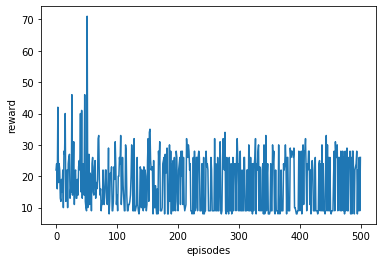

In [2]:
    #print plot
    plt.plot(epi, rew)
    #plt.title("") # title
    plt.ylabel("reward") # y label
    plt.xlabel("episodes") # x label
    plt.show()

    env.close() # need to close, or errors will be reported